# Análisis Exploratorio de Datos : Exploración visual de datasets de imágenes

**Estudiantes:** Diego Raúl Rivas Huanca,  Guerra Chura Joan Leonard
**Paper base:** Bertucci et al. (2023), *DendroMap: Visual Exploration of Large-Scale Image Datasets for Machine Learning with Treemaps*

Este notebook sigue las etapas del **ciclo de vida de Ciencia de Datos** y aplica
las técnicas del Aula 03 (visualización, medidas de posición y dispersión,
correlación) sobre un dataset de imágenes en lugar de un dataset tabular.

La idea central: CIFAR no tiene atributos. Se los construimos, y luego hacemos
EDA clásico sobre esos atributos derivados.

## Hipótesis
1. **Confluencia visual entre clases**  ¿hay clusters que mezclan clases, explicables por características visuales?
2. **Divergencia visual dentro de una clase**  ¿una clase se fragmenta en subgrupos visualmente distintos?
3. **Ambigüedad humana y calidad visual**  ¿las imágenes con más desacuerdo humano (CIFAR-10H) tienen un perfil visual propio?

## 0. Preparación del entorno

In [38]:
import os, sys, pickle, tarfile, urllib.request, hashlib, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import iqr, pearsonr, spearmanr, entropy as entropia_scipy
from scipy.cluster.hierarchy import linkage, fcluster

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["font.size"] = 11
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"

SEMILLA = 42
np.random.seed(SEMILLA)

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DIR_DATOS = RAIZ / "data"
DIR_RAW = DIR_DATOS / "raw"
DIR_PROC = DIR_DATOS / "processed"
DIR_FIG = RAIZ / "report" / "figures"
for d in (DIR_RAW, DIR_PROC, DIR_FIG):
    d.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(RAIZ))
from src import features as F

print("raíz del proyecto:", RAIZ)

raíz del proyecto: D:\TRABAJOS_2025B\GITHUB\cd-visual-analytics-cifar


Verificamos primero que el módulo de características funcione de forma aislada,
antes de lanzarlo sobre 60 000 imágenes.

In [39]:
F._pruebas()

OK: todas las pruebas de features.py pasaron
            brillo: [0.    1.    1.    0.757]
         contraste: [0.    0.    0.    0.192]
        saturacion: [0.    0.    1.    0.671]
          entropia: [-0.    -0.    -0.     7.405]
   densidad_bordes: [0.    0.    0.    0.986]
    tono_dominante: [-1 -1  0  3]
        unif_fondo: [0.    0.    0.    0.193]
   energia_central: [0.    0.    0.    1.014]


## 1. Adquisición de los datos

Fuente oficial: https://www.cs.toronto.edu/~kriz/cifar.html

Los archivos no se versionan en Git (superan el límite de GitHub). Esta celda los
descarga a `data/raw/` si aún no existen.

In [40]:
URLS = {
     "cifar-10-python.tar.gz":  "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz",
     "cifar-100-python.tar.gz": "https://www.cs.toronto.edu/~kriz/cifar-100-python.tar.gz",
}

# El nombre de la carpeta dentro del .tar.gz NO coincide con el nombre del
# archivo: CIFAR-10 se extrae a "cifar-10-batches-py", CIFAR-100 a
# "cifar-100-python". Se declara explícito para no adivinarlo del nombre del tar.
NOMBRES_CARPETA = {
    "cifar-10-python.tar.gz":  "cifar-10-batches-py",
    "cifar-100-python.tar.gz": "cifar-100-python",
}

def descargar_y_extraer(nombre, url):
    destino = DIR_RAW / nombre
    if not destino.exists():
        print(f"descargando {nombre} ...")
        urllib.request.urlretrieve(url, destino)
    carpeta = DIR_RAW / NOMBRES_CARPETA[nombre]
    if not carpeta.exists():
        with tarfile.open(destino) as t:
            t.extractall(DIR_RAW)
    return carpeta

CARPETA_C10 = descargar_y_extraer("cifar-10-python.tar.gz", URLS["cifar-10-python.tar.gz"])
print("listo:", CARPETA_C10)
print(sorted(p.name for p in CARPETA_C10.iterdir()))

listo: D:\TRABAJOS_2025B\GITHUB\cd-visual-analytics-cifar\data\raw\cifar-10-batches-py
['batches.meta', 'data_batch_1', 'data_batch_2', 'data_batch_3', 'data_batch_4', 'data_batch_5', 'readme.html', 'test_batch']


## 2. Formato original y wrangling

Los *batches* son diccionarios serializados con `pickle` de **Python 2**, así que
hay que leerlos con `encoding='bytes'` y las claves son `bytes`.

El punto delicado: `data` es `(10000, 3072)` ordenado **por canal** 1024 rojos,
1024 verdes, 1024 azules. Sin la transposición correcta las imágenes salen
irreconocibles y **no se emite ningún error**. Por eso la verificación visual del
paso siguiente no es opcional.

In [41]:
def cargar_batch(ruta):
    with open(ruta, "rb") as f:
        d = pickle.load(f, encoding="bytes")
    X = d[b"data"].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)  # -> (N, 32, 32, 3)
    y = np.array(d[b"labels"])
    return X, y

with open(CARPETA_C10 / "batches.meta", "rb") as f:
    meta = pickle.load(f, encoding="bytes")
NOMBRES_CLASE = [n.decode() for n in meta[b"label_names"]]

Xs, ys, splits = [], [], []
for i in range(1, 6):
    X, y = cargar_batch(CARPETA_C10 / f"data_batch_{i}")
    Xs.append(X); ys.append(y); splits.append(np.full(len(y), "train"))
X, y = cargar_batch(CARPETA_C10 / "test_batch")
Xs.append(X); ys.append(y); splits.append(np.full(len(y), "test"))

IMAGENES = np.concatenate(Xs)
ETIQUETAS = np.concatenate(ys)
SPLIT = np.concatenate(splits)
# indice dentro del test_batch, necesario luego para unir con CIFAR-10H
IDX_TEST = np.concatenate([np.full(50000, -1), np.arange(10000)])

del Xs, ys, splits
print("tensor de imágenes:", IMAGENES.shape, IMAGENES.dtype)
print("clases:", NOMBRES_CLASE)
print("memoria:", IMAGENES.nbytes / 1e6, "MB")

tensor de imágenes: (60000, 32, 32, 3) uint8
clases: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
memoria: 184.32 MB


### 2.1 Verificación visual de la reconstrucción

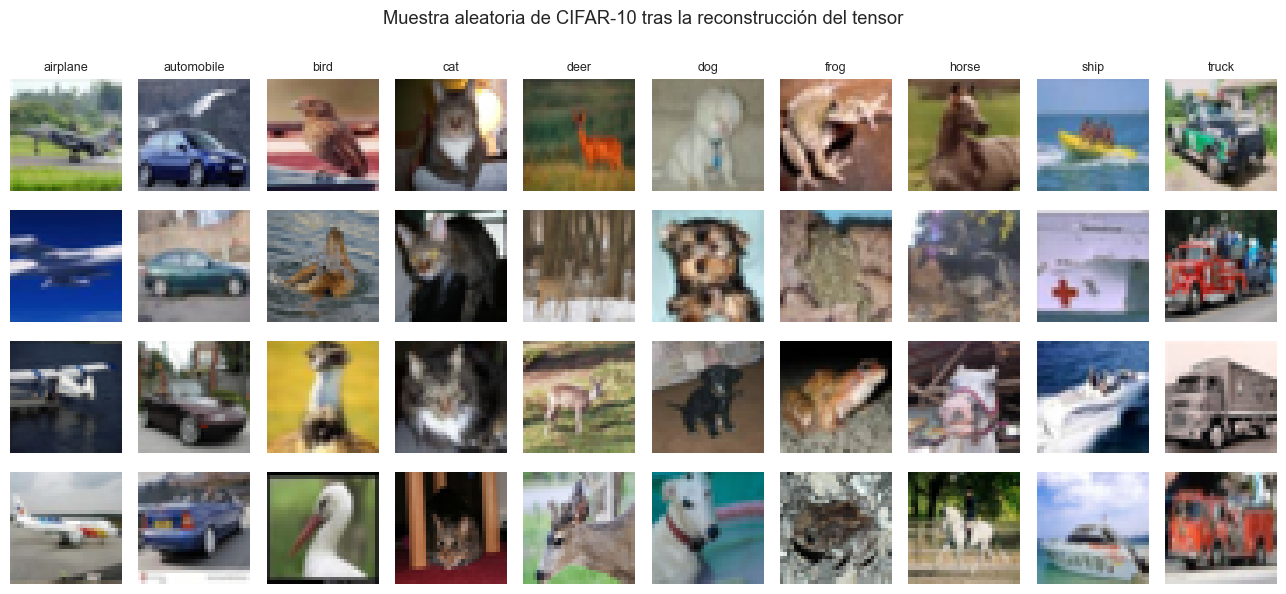

In [42]:
fig, axes = plt.subplots(4, 10, figsize=(13, 6))
for c in range(10):
    idx = np.where(ETIQUETAS == c)[0]
    muestra = np.random.choice(idx, 4, replace=False)
    for f_, i in enumerate(muestra):
        axes[f_, c].imshow(IMAGENES[i])
        axes[f_, c].axis("off")
    axes[0, c].set_title(NOMBRES_CLASE[c], fontsize=9)
fig.suptitle("Muestra aleatoria de CIFAR-10 tras la reconstrucción del tensor", y=1.0)
plt.tight_layout()
plt.savefig(DIR_FIG / "fig02_muestra_imagenes.png")
plt.show()

## 3. Descripción a nivel de registros

Cada fila = una imagen de 32×32×3. Granularidad: la instancia. Sin agregación.

split       test  train
clase                  
airplane    1000   5000
automobile  1000   5000
bird        1000   5000
cat         1000   5000
deer        1000   5000
dog         1000   5000
frog        1000   5000
horse       1000   5000
ship        1000   5000
truck       1000   5000

total: 60000


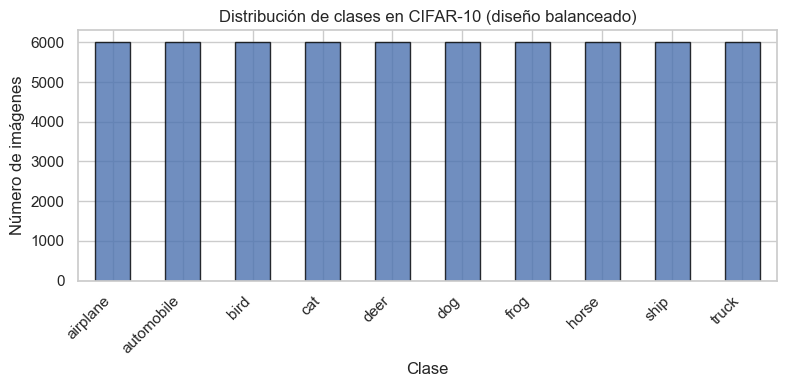

In [43]:
resumen = pd.DataFrame({
    "clase": [NOMBRES_CLASE[c] for c in ETIQUETAS],
    "split": SPLIT,
})
print(resumen.groupby(["clase", "split"]).size().unstack())
print("\ntotal:", len(resumen))

plt.figure(figsize=(8, 4))
resumen["clase"].value_counts().sort_index().plot(kind="bar", edgecolor="black", alpha=0.8)
plt.xlabel("Clase"); plt.ylabel("Número de imágenes")
plt.title("Distribución de clases en CIFAR-10 (diseño balanceado)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

El diseño es perfectamente balanceado: 6 000 por clase. Esto es útil de notar
porque significa que **cualquier desbalance que aparezca en los clusters proviene
de la estructura visual, no del muestreo**.

## 4. Feature engineering: dotar de atributos al dataset

Aquí está el núcleo del trabajo. Construimos 8 variables interpretables por
imagen. El detalle de cada fórmula está en `src/features.py`.

> La extracción sobre 60 000 imágenes toma varios minutos. El resultado se cachea
> en Parquet para no repetirla.

In [44]:
RUTA_CACHE = DIR_PROC / "caracteristicas_cifar10.parquet"

if RUTA_CACHE.exists():
    df = pd.read_parquet(RUTA_CACHE)
    print("cargado desde caché:", RUTA_CACHE)
else:
    print("extrayendo características (esto toma varios minutos)...")
    cols = F.extraer_lote(IMAGENES)
    df = pd.DataFrame(cols)
    df.insert(0, "img_id", np.arange(len(df)))
    df["clase"] = pd.Categorical([NOMBRES_CLASE[c] for c in ETIQUETAS])
    df["split"] = pd.Categorical(SPLIT)
    df["idx_test"] = IDX_TEST
    df.to_parquet(RUTA_CACHE, index=False)
    print("guardado en", RUTA_CACHE)

VARS_NUM = ["brillo", "contraste", "saturacion", "entropia",
            "densidad_bordes", "unif_fondo", "energia_central"]
df.head()

cargado desde caché: D:\TRABAJOS_2025B\GITHUB\cd-visual-analytics-cifar\data\processed\caracteristicas_cifar10.parquet


,img_id,brillo,contraste,saturacion,entropia,densidad_bordes,tono_dominante,unif_fondo,energia_central,clase,split,idx_test
0,0,0.554278,0.160367,0.573978,6.987637,0.925781,0,0.117477,1.671433,frog,train,-1
1,1,0.553328,0.235206,0.175088,7.650651,0.963867,7,0.224206,0.896884,truck,train,-1
2,2,0.546458,0.323613,0.127158,6.657644,0.696289,6,0.318725,0.694159,truck,train,-1
3,3,0.392092,0.128109,0.433660,6.624880,0.923828,1,0.081018,2.024335,deer,train,-1
4,4,0.473032,0.223171,0.315364,7.249648,0.838867,7,0.215358,0.941832,automobile,train,-1


## 5. Análisis exploratorio univariado

### 5.1 Resumen descriptivo con `describe()`

In [45]:
resumen_desc = df[VARS_NUM].describe().T
resumen_desc["IQR"] = resumen_desc["75%"] - resumen_desc["25%"]
resumen_desc["amplitud"] = resumen_desc["max"] - resumen_desc["min"]
resumen_desc["asimetria"] = df[VARS_NUM].skew()
resumen_desc.round(4)

,count,mean,std,min,25%,50%,75%,max,IQR,amplitud,asimetria
brillo,60000.0,0.5398,0.1282,0.0505,0.4561,0.5353,0.6207,0.9917,0.1645,0.9411,0.1179
contraste,60000.0,0.1962,0.0601,0.0165,0.1530,0.1946,0.2371,0.4509,0.0841,0.4344,0.1682
saturacion,60000.0,0.2736,0.1413,0.0000,0.1709,0.2549,0.3561,0.9843,0.1852,0.9843,0.7275
entropia,60000.0,6.9497,0.5791,0.8123,6.7426,7.0913,7.3294,7.7879,0.5868,6.9756,-2.2329
densidad_bordes,60000.0,0.8122,0.1441,0.0352,0.7539,0.8555,0.9150,0.9912,0.1611,0.9561,-1.6252
unif_fondo,60000.0,0.1760,0.0695,0.0001,0.1249,0.1725,0.2231,0.4408,0.0981,0.4407,0.2469
energia_central,60000.0,0.9653,0.4813,0.0040,0.6206,0.8967,1.2249,3.8281,0.6043,3.8240,1.0409


### 5.2 Medidas de posición y dispersión

Reportamos media, mediana, moda (sobre la versión discretizada), cuartiles,
desviación estándar, amplitud e IQR. La distancia entre media y mediana indica
asimetría.

In [46]:
filas = []
for v in VARS_NUM:
    x = df[v].values
    q1, q2, q3 = np.quantile(x, [0.25, 0.5, 0.75])
    # moda sobre la variable discretizada en 50 bins
    binned = np.floor((x - x.min()) / (x.max() - x.min() + 1e-12) * 50)
    moda_bin = Counter(binned).most_common(1)[0][0]
    filas.append({
        "variable": v, "media": x.mean(), "mediana": q2,
        "moda_aprox": x.min() + (moda_bin + 0.5) / 50 * (x.max() - x.min()),
        "Q1": q1, "Q3": q3, "desv_est": x.std(ddof=1),
        "IQR": q3 - q1, "amplitud": x.max() - x.min(),
    })
tabla_posicion = pd.DataFrame(filas).set_index("variable").round(4)
tabla_posicion

,media,mediana,moda_aprox,Q1,Q3,desv_est,IQR,amplitud
variable,,,,,,,,
brillo,0.5398,0.5353,0.5305,0.4561,0.6207,0.1282,0.1645,0.9411
contraste,0.1962,0.1946,0.1860,0.1530,0.2371,0.0601,0.0841,0.4344
saturacion,0.2736,0.2549,0.2264,0.1709,0.3561,0.1413,0.1852,0.9843
entropia,6.9497,7.0913,7.2996,6.7426,7.3294,0.5791,0.5868,6.9756
densidad_bordes,0.8122,0.8555,0.9243,0.7539,0.9150,0.1441,0.1611,0.9561
unif_fondo,0.1760,0.1725,0.1543,0.1249,0.2231,0.0695,0.0981,0.4407
energia_central,0.9653,0.8967,0.8071,0.6206,1.2249,0.4813,0.6043,3.8240


### 5.3 Histogramas con media y mediana

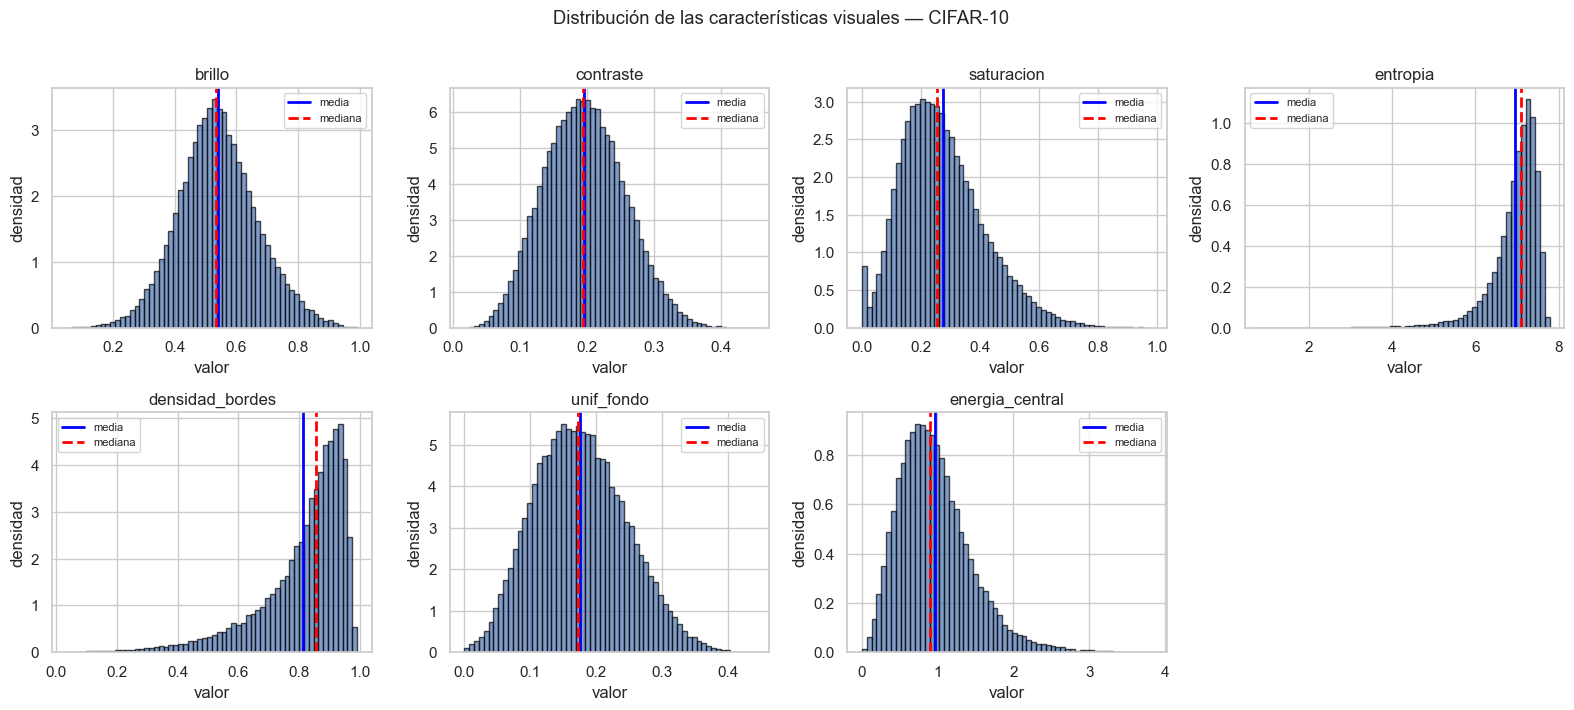

In [47]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, v in zip(axes.flat, VARS_NUM):
    x = df[v].values
    ax.hist(x, bins=60, density=True, edgecolor="black", alpha=0.7)
    ax.axvline(x.mean(), color="blue", lw=2, label="media")
    ax.axvline(np.median(x), color="red", lw=2, ls="--", label="mediana")
    ax.set_title(v); ax.set_xlabel("valor"); ax.set_ylabel("densidad")
    ax.legend(fontsize=8)
axes.flat[-1].axis("off")
fig.suptitle("Distribución de las características visuales — CIFAR-10", y=1.01)
plt.tight_layout()
plt.savefig(DIR_FIG / "fig03_histogramas_caracteristicas.png")
plt.show()

### 5.4 Boxplots por clase

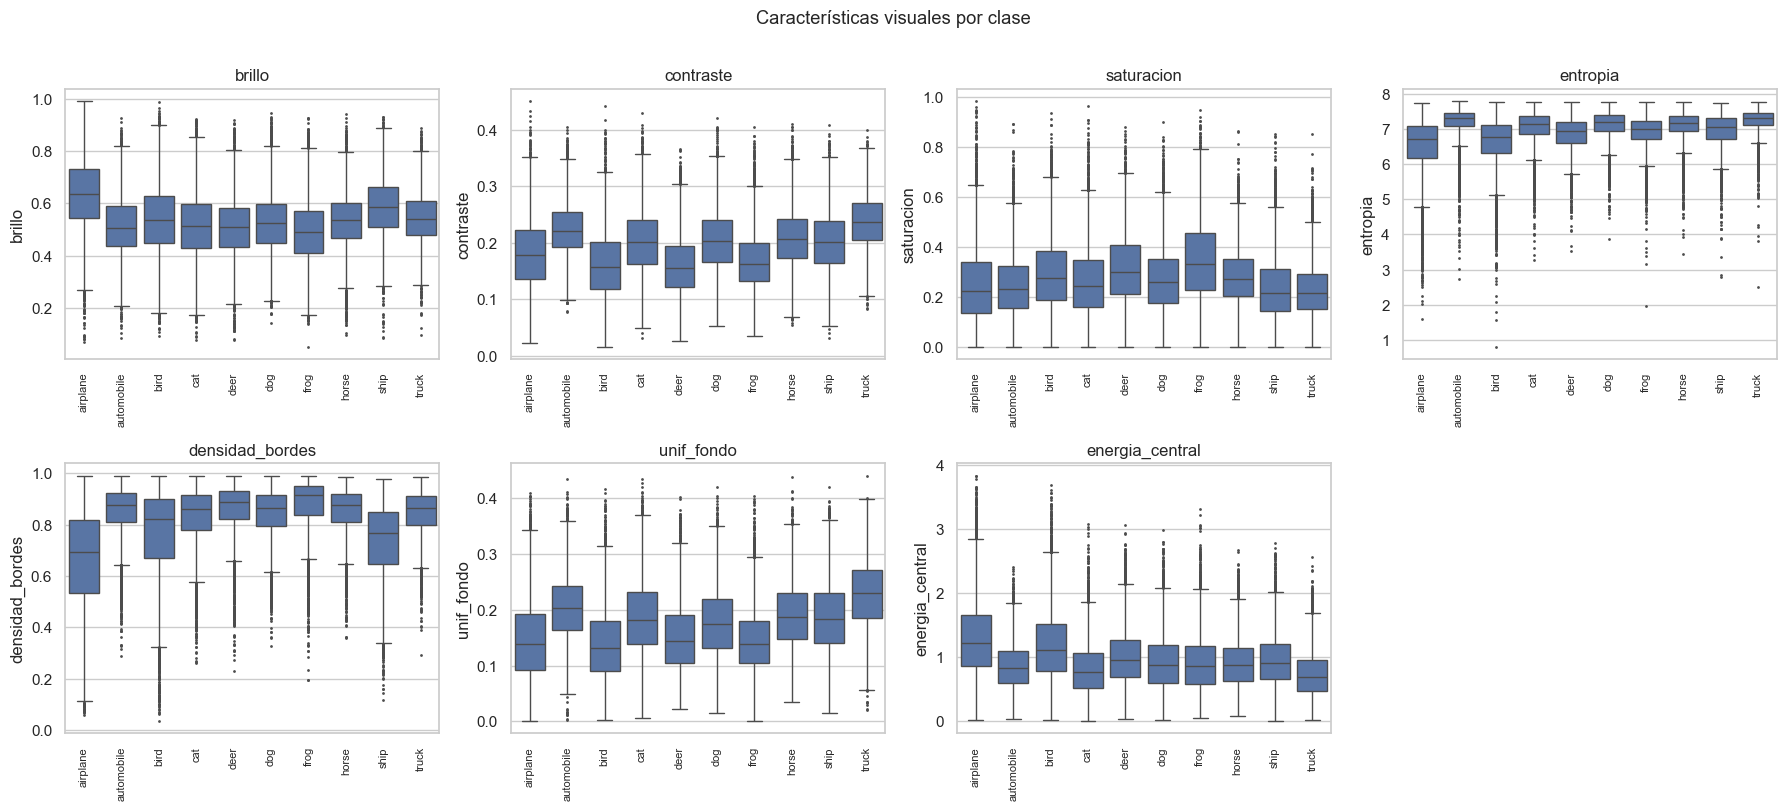

In [48]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
orden = sorted(df["clase"].unique())
for ax, v in zip(axes.flat, VARS_NUM):
    sns.boxplot(data=df, x="clase", y=v, order=orden, ax=ax, fliersize=1)
    ax.set_title(v); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=90, labelsize=8)
axes.flat[-1].axis("off")
fig.suptitle("Características visuales por clase", y=1.01)
plt.tight_layout()
plt.savefig(DIR_FIG / "fig04_boxplots_por_clase.png")
plt.show()

### 5.5 Violin plot de una característica discriminante

El violin plot añade la forma de la densidad sobre el resumen del boxplot: revela
si una clase es **bimodal**, lo cual es evidencia directa a favor de la Hipótesis 2.

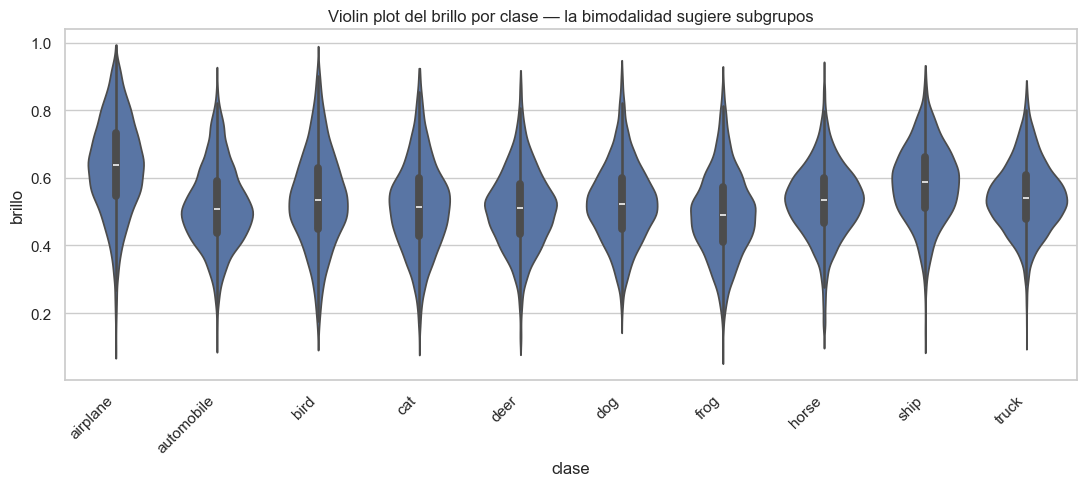

In [49]:
plt.figure(figsize=(11, 5))
sns.violinplot(data=df, x="clase", y="brillo", order=orden, cut=0)
plt.title("Violin plot del brillo por clase — la bimodalidad sugiere subgrupos")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 6. Calidad de los datos

Tres diagnósticos: duplicados, imágenes degeneradas y valores atípicos.

In [50]:
# --- duplicados exactos por hash del tensor
hashes = [hashlib.md5(IMAGENES[i].tobytes()).hexdigest() for i in range(len(IMAGENES))]
serie_hash = pd.Series(hashes)
dups = serie_hash.duplicated(keep=False)
n_dup = int(dups.sum())
grupos_dup = serie_hash[dups].nunique()

# --- imágenes degeneradas (varianza casi nula)
degeneradas = df["contraste"] < 1e-3

# --- atípicos por criterio 1.5*IQR
info_atipicos = {}
mask_atipico = pd.Series(False, index=df.index)
for v in VARS_NUM:
    q1, q3 = np.quantile(df[v], [0.25, 0.75])
    r = q3 - q1
    m = (df[v] < q1 - 1.5 * r) | (df[v] > q3 + 1.5 * r)
    info_atipicos[v] = m.mean() * 100
    mask_atipico |= m

df["es_atipico"] = mask_atipico
df["es_duplicado"] = dups.values

print(f"duplicados exactos: {n_dup} imágenes en {grupos_dup} grupos")
print(f"imágenes degeneradas (contraste ~ 0): {int(degeneradas.sum())}")
print(f"registros con al menos un atípico: {int(mask_atipico.sum())} "
      f"({mask_atipico.mean()*100:.2f}%)")

duplicados exactos: 0 imágenes en 0 grupos
imágenes degeneradas (contraste ~ 0): 0
registros con al menos un atípico: 6007 (10.01%)


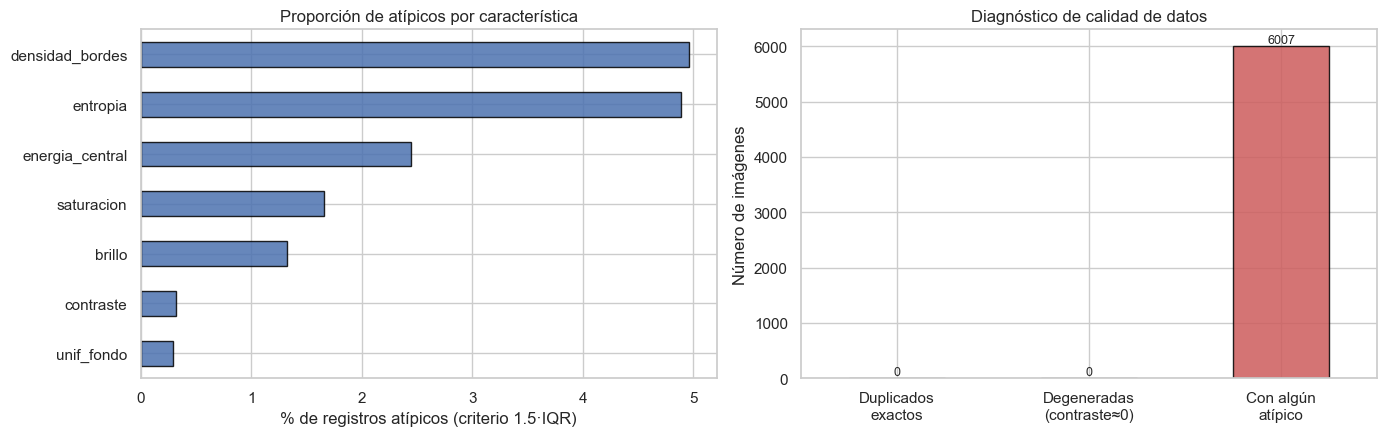

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

pd.Series(info_atipicos).sort_values().plot(kind="barh", ax=axes[0],
                                            edgecolor="black", alpha=0.85)
axes[0].set_xlabel("% de registros atípicos (criterio 1.5·IQR)")
axes[0].set_title("Proporción de atípicos por característica")

conteos = pd.Series({
    "Duplicados\nexactos": n_dup,
    "Degeneradas\n(contraste≈0)": int(degeneradas.sum()),
    "Con algún\natípico": int(mask_atipico.sum()),
})
conteos.plot(kind="bar", ax=axes[1], edgecolor="black", alpha=0.85, color="indianred")
axes[1].set_ylabel("Número de imágenes")
axes[1].set_title("Diagnóstico de calidad de datos")
axes[1].tick_params(axis="x", rotation=0)
for i, v in enumerate(conteos):
    axes[1].text(i, v, str(v), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(DIR_FIG / "fig07_calidad_datos.png")
plt.show()

**Decisión de wrangling:** los atípicos se **marcan**, no se eliminan. En este
proyecto los extremos son justamente lo interesante señalan imágenes de baja
calidad, que son candidatas a explicar subgrupos con bajo rendimiento.

## 7. Análisis bivariado: correlaciones

Reportamos Pearson y Spearman. La diferencia entre ambos delata relaciones
monótonas no lineales, como se vio en el Aula 03 con `log(x)`.

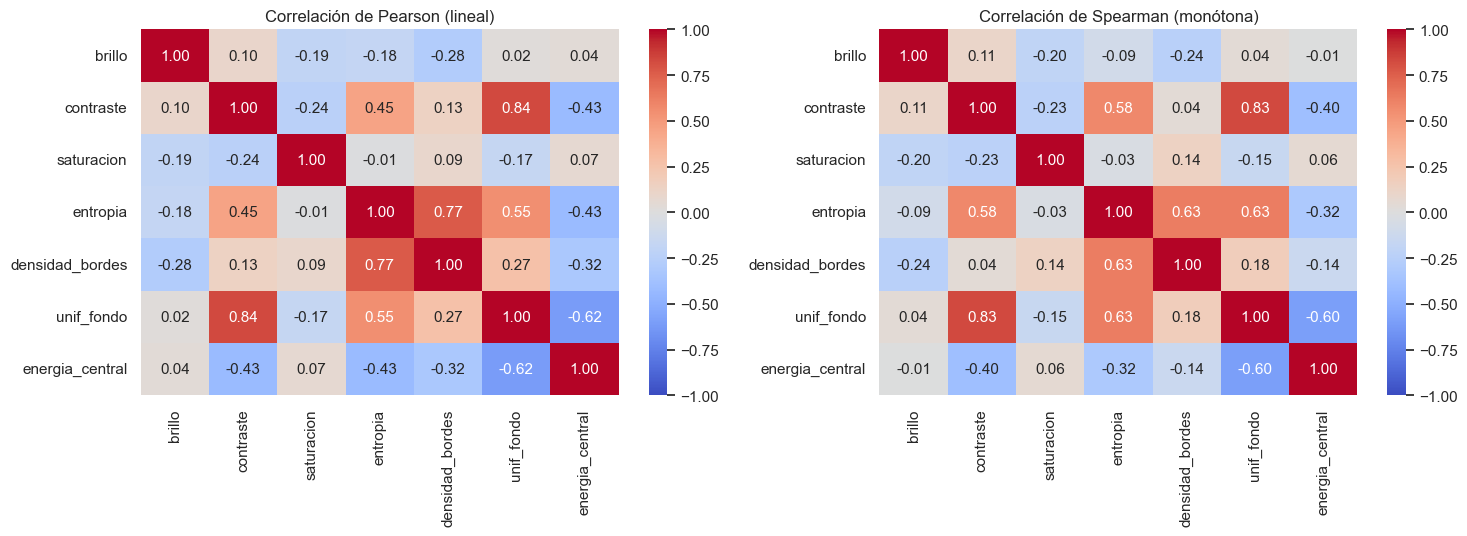

In [52]:
corr_p = df[VARS_NUM].corr(method="pearson")
corr_s = df[VARS_NUM].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
sns.heatmap(corr_p, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Correlación de Pearson (lineal)")
sns.heatmap(corr_s, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Correlación de Spearman (monótona)")
plt.tight_layout()
plt.savefig(DIR_FIG / "fig05_matriz_correlacion.png")
plt.show()

In [53]:
pares_informe = [
    ("entropia", "densidad_bordes"),
    ("brillo", "contraste"),
    ("saturacion", "brillo"),
    ("unif_fondo", "densidad_bordes"),
    ("energia_central", "contraste"),
]
print("Pares reportados en la Tabla 6.3 del informe:")
for a, b in pares_informe:
    print(f"  {a:>16} vs {b:<16}  Pearson={corr_p.loc[a,b]:+.3f}  Spearman={corr_s.loc[a,b]:+.3f}")

Pares reportados en la Tabla 6.3 del informe:
          entropia vs densidad_bordes   Pearson=+0.770  Spearman=+0.630
            brillo vs contraste         Pearson=+0.099  Spearman=+0.109
        saturacion vs brillo            Pearson=-0.195  Spearman=-0.198
        unif_fondo vs densidad_bordes   Pearson=+0.273  Spearman=+0.176
   energia_central vs contraste         Pearson=-0.428  Spearman=-0.395


In [54]:
# pares donde Pearson y Spearman más difieren => relación monótona no lineal
pares = []
for i, a in enumerate(VARS_NUM):
    for b in VARS_NUM[i+1:]:
        pares.append({"A": a, "B": b,
                      "pearson": corr_p.loc[a, b],
                      "spearman": corr_s.loc[a, b],
                      "brecha": abs(corr_p.loc[a, b] - corr_s.loc[a, b])})
tabla_corr = pd.DataFrame(pares).sort_values("brecha", ascending=False)
tabla_corr.round(3).head(10)

,A,B,pearson,spearman,brecha
19,densidad_bordes,energia_central,-0.321,-0.140,0.181
15,entropia,densidad_bordes,0.770,0.630,0.140
7,contraste,entropia,0.448,0.582,0.134
17,entropia,energia_central,-0.426,-0.316,0.111
18,densidad_bordes,unif_fondo,0.273,0.176,0.097
8,contraste,densidad_bordes,0.133,0.040,0.093
2,brillo,entropia,-0.178,-0.092,0.086
16,entropia,unif_fondo,0.549,0.627,0.078
12,saturacion,densidad_bordes,0.088,0.139,0.051
5,brillo,energia_central,0.037,-0.007,0.044


### 7.1 Pair plot

Nunca interpretar un coeficiente sin ver el scatterplot — lección del cuarteto de
Anscombe. Usamos una submuestra estratificada para que el gráfico sea legible.

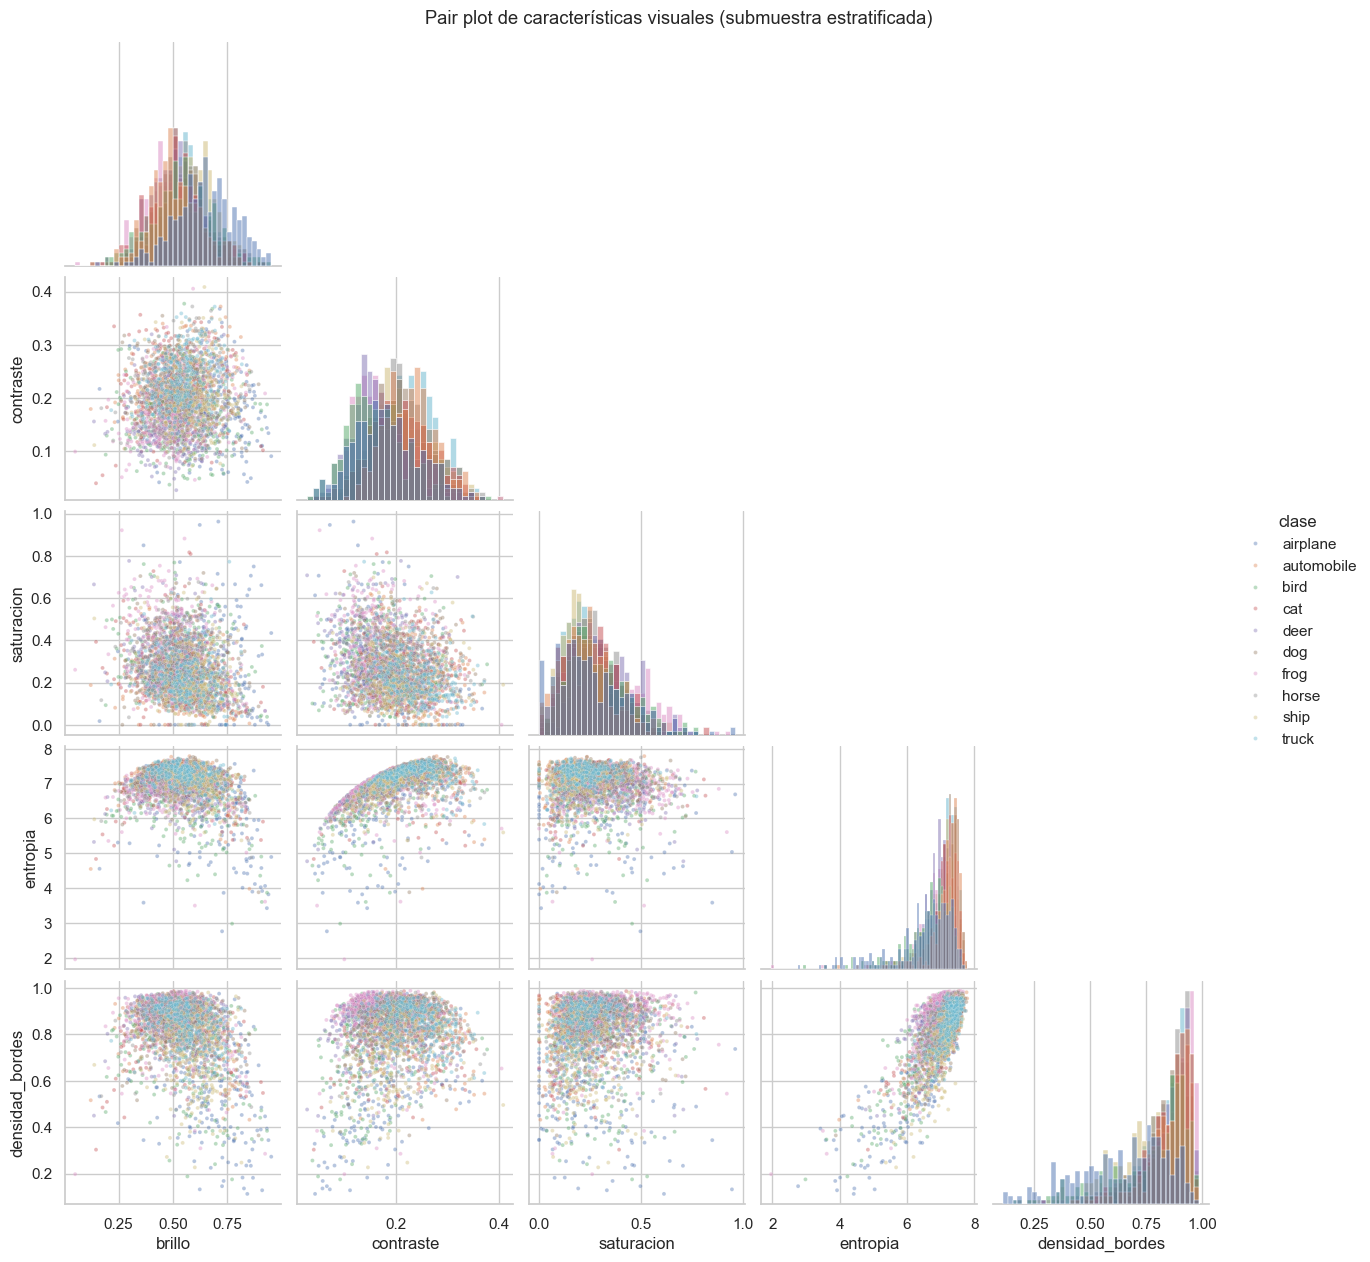

In [55]:
sub = df.groupby("clase", observed=True).sample(300, random_state=SEMILLA)
g = sns.pairplot(sub, vars=VARS_NUM[:5], hue="clase", diag_kind="hist",
                 corner=True, plot_kws={"s": 8, "alpha": 0.4})
g.fig.suptitle("Pair plot de características visuales (submuestra estratificada)", y=1.01)
g.savefig(DIR_FIG / "fig06_pairplot_caracteristicas.png")
plt.show()

## 8. Embeddings y clustering jerárquico

Reproducimos el procedimiento de DendroMap: embeddings de ResNet50 +
aglomerativo con enlace de Ward y distancia euclidiana.

> **Nota de costo.** El clustering aglomerativo es `O(n²)` en memoria. Con 60 000
> imágenes la matriz de distancias no entra en RAM. Trabajamos sobre una
> submuestra estratificada de 10 000 imágenes (el mismo tamaño que usa DendroMap
> en su experimento de preservación de distancias) y cacheamos el resultado.

In [56]:
RUTA_EMB = DIR_PROC / "embeddings_resnet50.npy"
RUTA_IDX = DIR_PROC / "indices_submuestra.npy"
N_SUB = 10000

if RUTA_EMB.exists():
    EMB = np.load(RUTA_EMB)
    IDX_SUB = np.load(RUTA_IDX)
    print("embeddings cargados desde caché:", EMB.shape)
else:
    import torch, torchvision
    from torchvision import transforms

    IDX_SUB = (df.groupby("clase", observed=True)
                 .sample(N_SUB // 10, random_state=SEMILLA)
                 .index.values)
    IDX_SUB.sort()

    disp = "cuda" if torch.cuda.is_available() else "cpu"
    print("dispositivo:", disp)

    modelo = torchvision.models.resnet50(weights="IMAGENET1K_V2")
    modelo.fc = torch.nn.Identity()   # salida de 2048-D del avgpool
    modelo.eval().to(disp)

    tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize((224, 224), antialias=True),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

    salidas = []
    LOTE = 128
    with torch.no_grad():
        for i in range(0, len(IDX_SUB), LOTE):
            lote = IDX_SUB[i:i+LOTE]
            t = torch.stack([tf(IMAGENES[j]) for j in lote]).to(disp)
            salidas.append(modelo(t).cpu().numpy())
            if (i // LOTE) % 10 == 0:
                print(f"  {i}/{len(IDX_SUB)}")
    EMB = np.concatenate(salidas).astype(np.float32)
    np.save(RUTA_EMB, EMB)
    np.save(RUTA_IDX, IDX_SUB)
    print("embeddings:", EMB.shape)

embeddings cargados desde caché: (10000, 2048)


In [57]:
# Clustering aglomerativo con enlace de Ward (igual que DendroMap)
Z = linkage(EMB, method="ward", metric="euclidean")

dsub = df.loc[IDX_SUB].copy().reset_index(drop=True)
for k in (8, 18):
    dsub[f"cluster_k{k}"] = fcluster(Z, t=k, criterion="maxclust")

print(dsub["cluster_k8"].value_counts().sort_index())

cluster_k8
1     348
2    1358
3    1949
4     724
5    1645
6    2067
7     587
8    1322
Name: count, dtype: int64


## 9. Hipótesis 1 : confluencia visual entre clases

¿Hay clusters que mezclan clases semánticamente distintas, y qué características
visuales comparten esas imágenes?

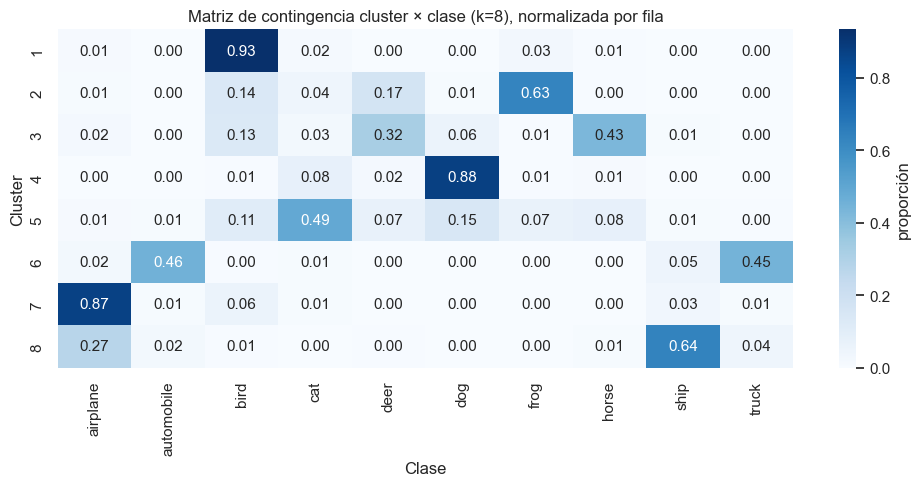


Pureza por cluster (1.0 = una sola clase):
cluster_k8
3    0.427
6    0.456
5    0.491
2    0.632
8    0.635
7    0.874
4    0.876
1    0.934
dtype: float64

Clusters mixtos (pureza < 0.6): [3, 6, 5]


In [58]:
cont = pd.crosstab(dsub["cluster_k8"], dsub["clase"], normalize="index")

plt.figure(figsize=(10, 5))
sns.heatmap(cont, annot=True, fmt=".2f", cmap="Blues", cbar_kws={"label": "proporción"})
plt.title("Matriz de contingencia cluster × clase (k=8), normalizada por fila")
plt.xlabel("Clase"); plt.ylabel("Cluster")
plt.tight_layout()
plt.savefig(DIR_FIG / "fig08_h1_matriz_clase_cluster.png")
plt.show()

# pureza de cada cluster = proporción de la clase mayoritaria
pureza = cont.max(axis=1).sort_values()
print("\nPureza por cluster (1.0 = una sola clase):")
print(pureza.round(3))
CLUSTERS_MIXTOS = pureza[pureza < 0.6].index.tolist()
print("\nClusters mixtos (pureza < 0.6):", CLUSTERS_MIXTOS)

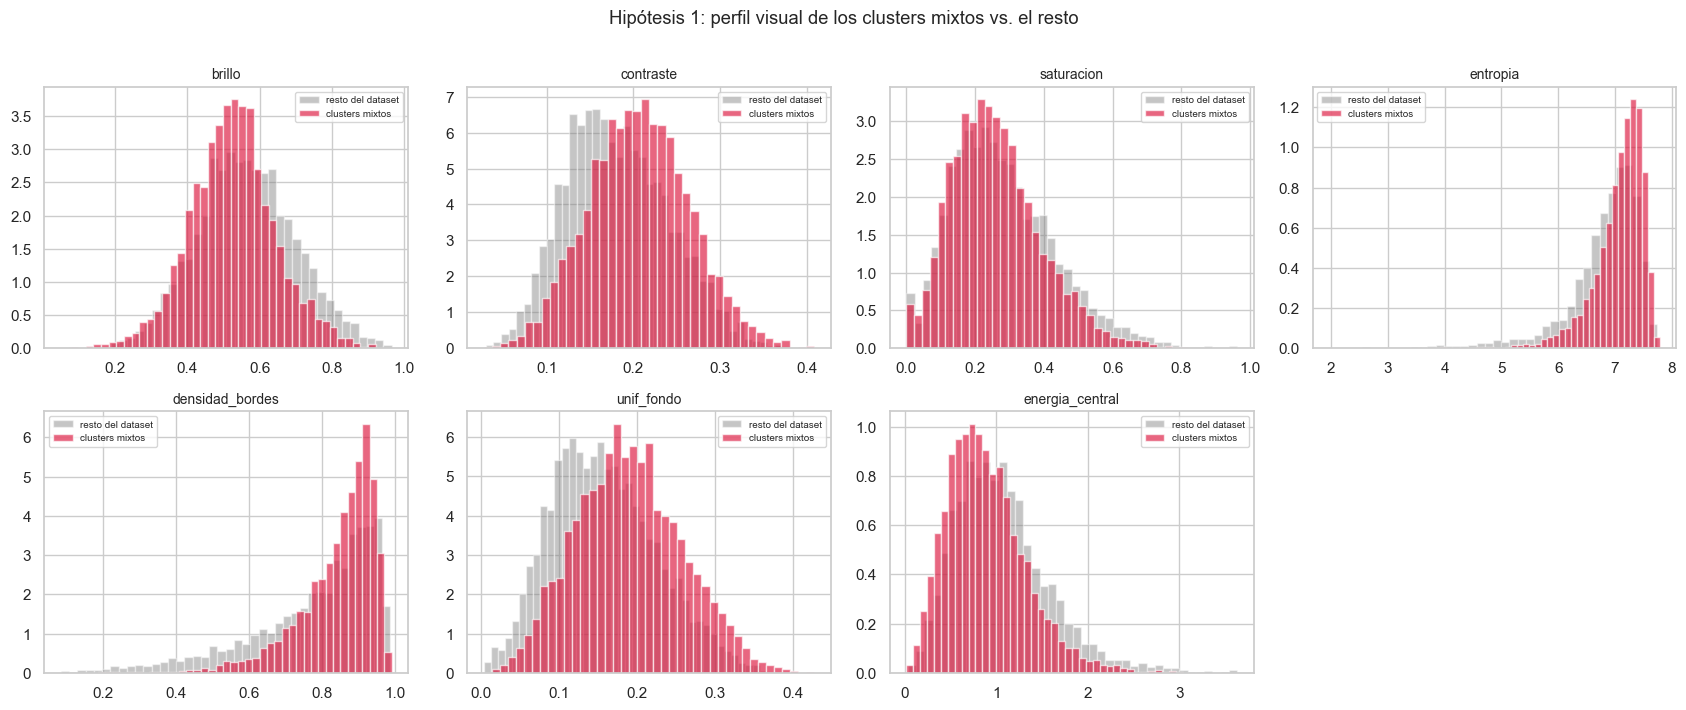


d de Cohen (mixtos vs. resto):
            brillo: -0.297
         contraste: +0.432
        saturacion: -0.144
          entropia: +0.465
   densidad_bordes: +0.476
        unif_fondo: +0.490
   energia_central: -0.368


In [59]:
# Perfil visual de los clusters mixtos frente al resto del dataset
fig, axes = plt.subplots(2, 4, figsize=(17, 7))
en_mixto = dsub["cluster_k8"].isin(CLUSTERS_MIXTOS)
for ax, v in zip(axes.flat, VARS_NUM):
    ax.hist(dsub.loc[~en_mixto, v], bins=40, density=True, alpha=0.45,
            color="gray", label="resto del dataset")
    ax.hist(dsub.loc[en_mixto, v], bins=40, density=True, alpha=0.65,
            color="crimson", label="clusters mixtos")
    ax.set_title(v, fontsize=10); ax.legend(fontsize=7)
axes.flat[-1].axis("off")
fig.suptitle("Hipótesis 1: perfil visual de los clusters mixtos vs. el resto", y=1.01)
plt.tight_layout()
plt.savefig(DIR_FIG / "fig09_h1_perfil_clusters.png")
plt.show()

# tamaño del efecto: d de Cohen por característica
print("\nd de Cohen (mixtos vs. resto):")
for v in VARS_NUM:
    a, b = dsub.loc[en_mixto, v], dsub.loc[~en_mixto, v]
    s = np.sqrt(((len(a)-1)*a.var() + (len(b)-1)*b.var()) / (len(a)+len(b)-2))
    print(f"  {v:>16}: {(a.mean()-b.mean())/s:+.3f}")

**Conclusión intermedia H1:** Se confirma. Con k=8, tres de los ocho clusters
mezclan más de una clase de forma sustancial: el cluster 3 (pureza 0.427), el
cluster 6 (pureza 0.456) y el cluster 5 (pureza 0.491), frente a 0.87–0.93 de
los clusters más homogéneos. El análisis de tamaño del efecto (d de Cohen)
muestra que estos clusters mixtos se distinguen del resto principalmente por
mayor `unif_fondo` (d=+0.49), mayor `densidad_bordes` (d=+0.48) y mayor
`entropia` (d=+0.47), efectos de la  magnitud media. Las clases confluyen cuando
comparten fondos poco uniformes y alta textura, no necesariamente color o forma
del objeto.

## 10. Hipótesis 2 : divergencia visual dentro de una clase

Medimos la fragmentación de cada clase mediante la entropía de su distribución
sobre los clusters. Entropía alta = la clase se reparte en muchos clusters.

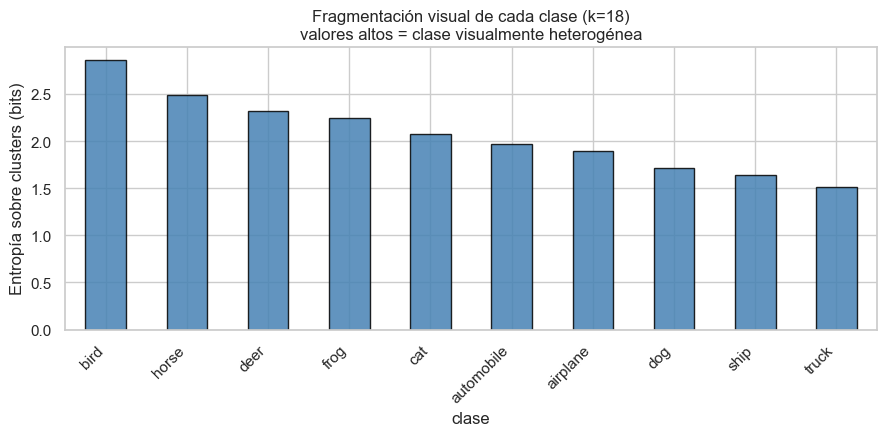

clase más fragmentada: bird


In [60]:
cont_cc = pd.crosstab(dsub["clase"], dsub["cluster_k18"], normalize="index")
fragmentacion = cont_cc.apply(lambda r: entropia_scipy(r[r > 0], base=2), axis=1)
fragmentacion = fragmentacion.sort_values(ascending=False)

plt.figure(figsize=(9, 4.5))
fragmentacion.plot(kind="bar", edgecolor="black", alpha=0.85, color="steelblue")
plt.ylabel("Entropía sobre clusters (bits)")
plt.title("Fragmentación visual de cada clase (k=18)\nvalores altos = clase visualmente heterogénea")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(DIR_FIG / "fig10_h2_fragmentacion_clases.png")
plt.show()

CLASE_FRAG = fragmentacion.index[0]
print("clase más fragmentada:", CLASE_FRAG)

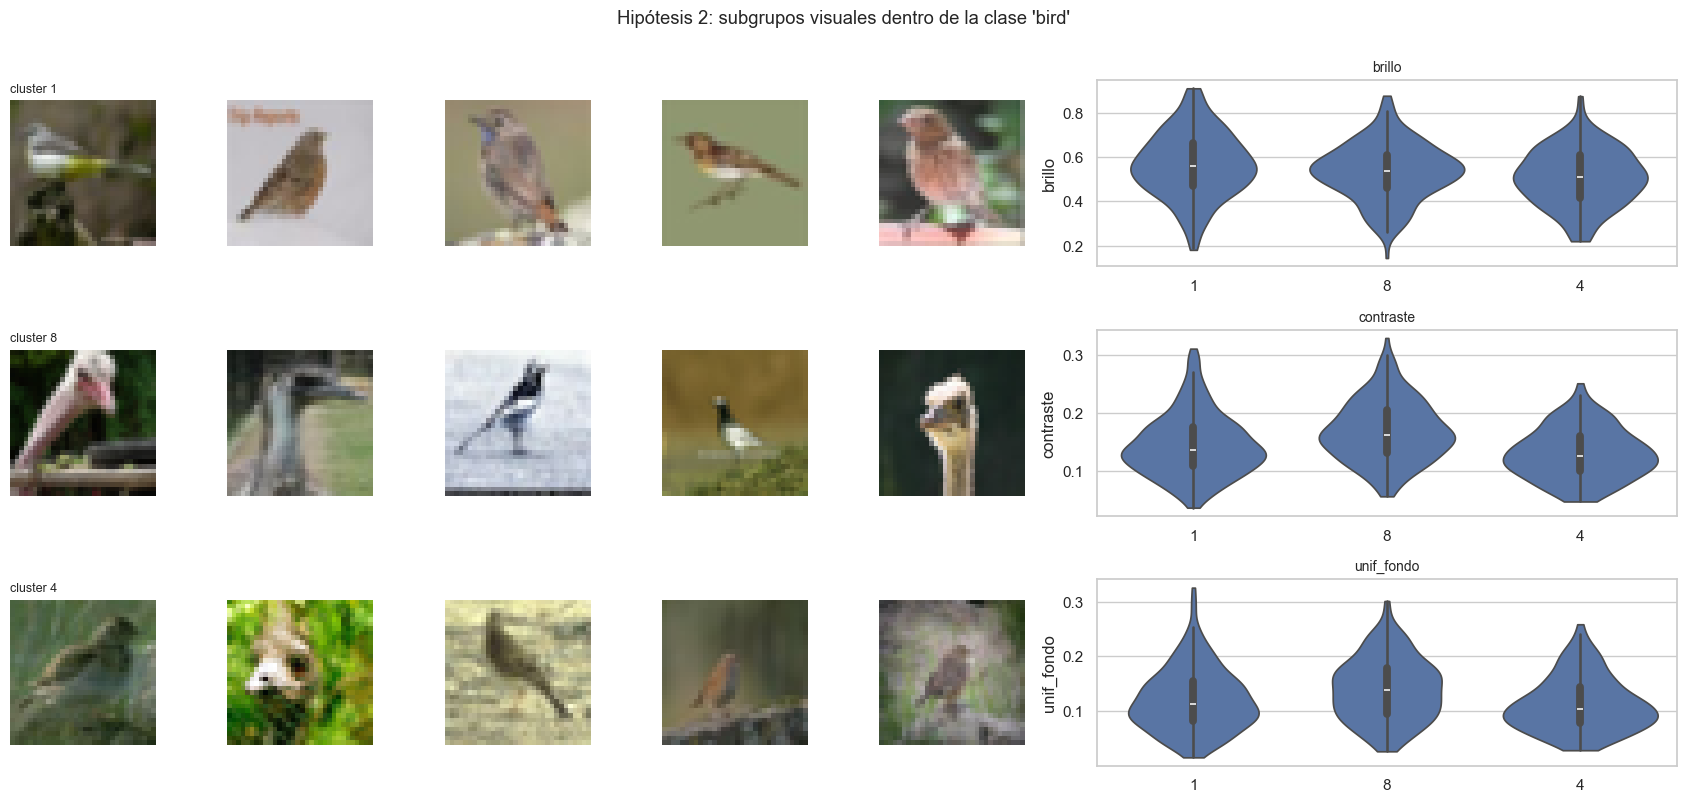

In [61]:
# Subgrupos dentro de la clase más fragmentada
sel = dsub[dsub["clase"] == CLASE_FRAG]
principales = sel["cluster_k18"].value_counts().head(3).index.tolist()

fig = plt.figure(figsize=(17, 8))
gs = fig.add_gridspec(3, 8)

for fila, cl in enumerate(principales):
    idxs = sel[sel["cluster_k18"] == cl].index[:5]
    for col, i in enumerate(idxs):
        ax = fig.add_subplot(gs[fila, col])
        ax.imshow(IMAGENES[IDX_SUB[i]])
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(f"C{cl}")
            ax.set_title(f"cluster {cl}", fontsize=9, loc="left")

for j, v in enumerate(["brillo", "contraste", "unif_fondo"]):
    ax = fig.add_subplot(gs[j, 5:])
    sns.violinplot(data=sel[sel["cluster_k18"].isin(principales)],
                   x="cluster_k18", y=v, ax=ax, cut=0, order=principales)
    ax.set_title(v, fontsize=10); ax.set_xlabel("")

fig.suptitle(f"Hipótesis 2: subgrupos visuales dentro de la clase '{CLASE_FRAG}'", y=1.0)
plt.tight_layout()
plt.savefig(DIR_FIG / "fig11_h2_subgrupos_clase.png")
plt.show()

**Conclusión intermedia H3:** No se confirma. Los ρ de Spearman más altos en
magnitud son `brillo` (ρ=-0.089, p=5.6e-19) y `contraste` (ρ=-0.081,
p=4.4e-16); todos los demás son aún más débiles, y `saturacion` no resulta
significativa (ρ=-0.005, p=0.614). Con n=10 000, incluso correlaciones
triviales (|ρ|<0.1) salen estadísticamente significativas, la misma lección
del cuarteto de Anscombe del Aula 03, vista aquí al revés: significancia
estadística no implica relevancia práctica. Ninguna de las ocho características
visuales de bajo nivel explica de forma sustancial la ambigüedad percibida por
humanos; esta parece depender de factores semánticos (confusión entre clases
como `cat`/`dog` o `automobile`/`truck`) que un análisis a nivel de píxel no
captura. No se hizo el cruce ambigüedad × cluster de forma explícita en este
notebook, queda como línea futura, dado que el efecto principal ya resultó
negativo a nivel de característica individual.

## 11. Cruce con datos externos: CIFAR-10H

Aquí replicamos la estrategia del laboratorio de Hubway, donde se cruzó el
dataset principal con datos externos de clima. El análogo para imágenes es
**CIFAR-10H** (Peterson et al., 2019): ~50 anotaciones humanas por cada una de
las 10 000 imágenes del conjunto de prueba.

El link es https://github.com/jcpeterson/cifar-10h/tree/master/data.

De ahí derivamos dos variables nuevas:
- `entropia_humana`: entropía de la distribución de votos (0 = consenso unánime).
- `consenso`: proporción de votos a la clase mayoritaria.

> Si la descarga automática falla, bajar `cifar10h-counts.npy` manualmente desde
> el repositorio `jcpeterson/cifar-10h` y colocarlo en `data/raw/`.

In [62]:
RUTA_H = DIR_RAW / "cifar10h-counts.npy"
URL_H = ("https://raw.githubusercontent.com/jcpeterson/cifar-10h/master/data/"
         "cifar10h-counts.npy")

if not RUTA_H.exists():
    try:
        urllib.request.urlretrieve(URL_H, RUTA_H)
    except Exception as e:
        print("descarga automática falló:", e)

if RUTA_H.exists():
    votos = np.load(RUTA_H)            # (10000, 10) conteos por clase
    print("matriz de votos:", votos.shape, "— votos por imagen:", votos.sum(1).mean())

    p = votos / votos.sum(1, keepdims=True)
    ent_humana = np.array([entropia_scipy(r[r > 0], base=2) for r in p])
    consenso = p.max(1)

    aux = pd.DataFrame({"idx_test": np.arange(len(votos)),
                        "entropia_humana": ent_humana,
                        "consenso": consenso})
    df = df.merge(aux, on="idx_test", how="left")

    # validación del cruce: la clase mayoritaria humana debe coincidir
    # casi siempre con la etiqueta oficial
    mayoritaria = np.array(NOMBRES_CLASE)[votos.argmax(1)]
    oficial = df.loc[df["split"] == "test"].sort_values("idx_test")["clase"].values
    print("coincidencia clase mayoritaria vs. etiqueta oficial:",
          f"{(mayoritaria == oficial).mean():.4f}")
else:
    print("CIFAR-10H no disponible; la sección H3 queda pendiente.")

matriz de votos: (10000, 10) — votos por imagen: 51.1
coincidencia clase mayoritaria vs. etiqueta oficial: 0.9921


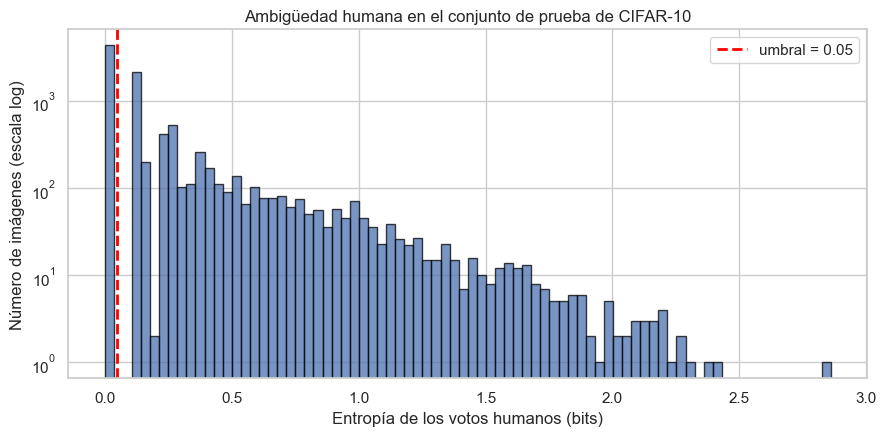

imágenes de consenso unánime: 4393
imágenes ambiguas:            5607


In [63]:
dtest = df[df["split"] == "test"].dropna(subset=["entropia_humana"])
UMBRAL = 0.05  # por debajo: consenso prácticamente unánime

plt.figure(figsize=(9, 4.5))
plt.hist(dtest["entropia_humana"], bins=80, edgecolor="black", alpha=0.75)
plt.axvline(UMBRAL, color="red", ls="--", lw=2, label=f"umbral = {UMBRAL}")
plt.yscale("log")
plt.xlabel("Entropía de los votos humanos (bits)")
plt.ylabel("Número de imágenes (escala log)")
plt.title("Ambigüedad humana en el conjunto de prueba de CIFAR-10")
plt.legend()
plt.tight_layout()
plt.savefig(DIR_FIG / "fig12_h3_ambiguedad_distribucion.png")
plt.show()

print(f"imágenes de consenso unánime: {(dtest['entropia_humana'] <= UMBRAL).sum()}")
print(f"imágenes ambiguas:            {(dtest['entropia_humana'] >  UMBRAL).sum()}")

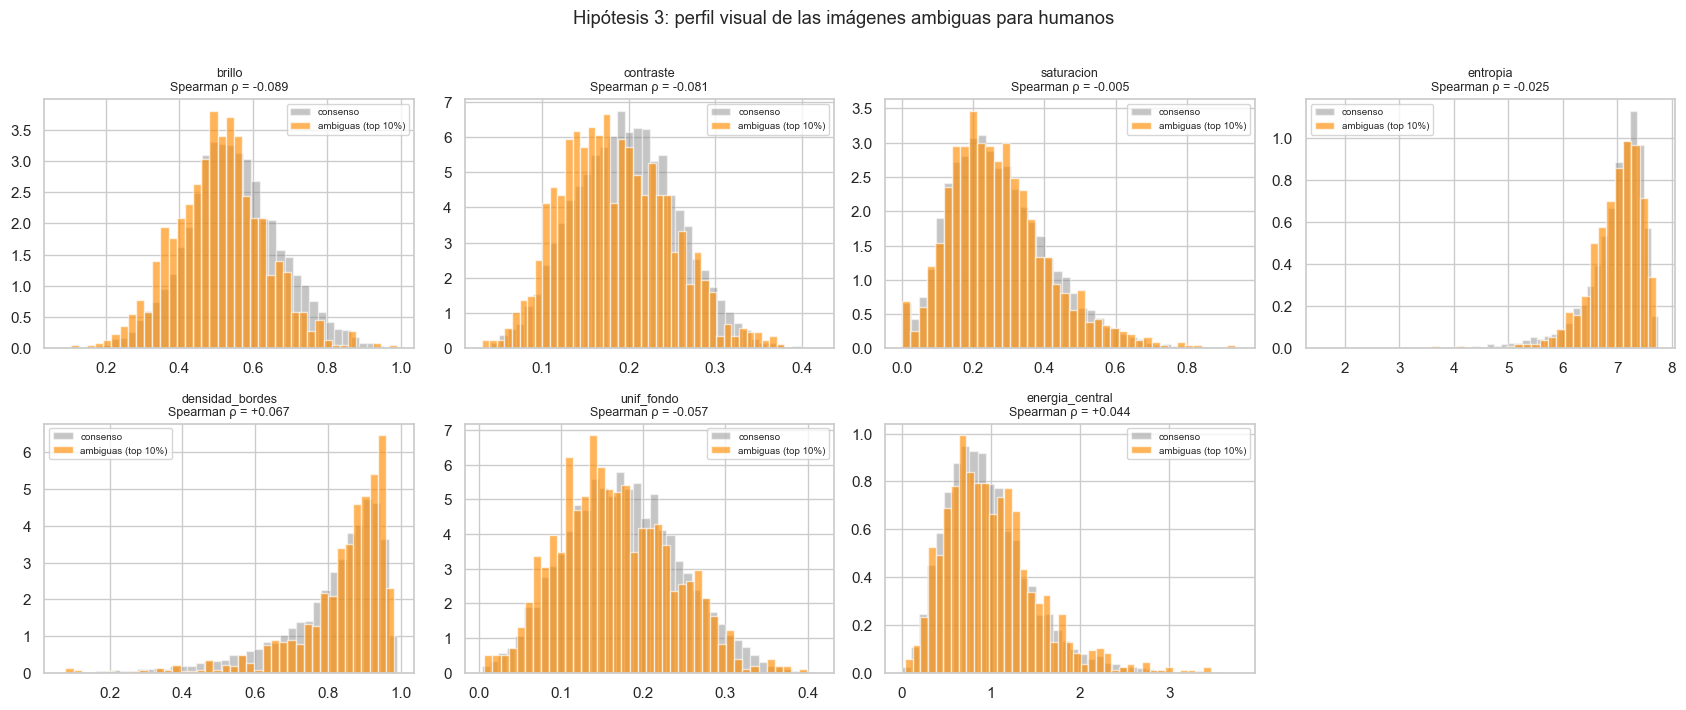

In [64]:
ambigua = dtest["entropia_humana"] > dtest["entropia_humana"].quantile(0.90)

fig, axes = plt.subplots(2, 4, figsize=(17, 7))
for ax, v in zip(axes.flat, VARS_NUM):
    ax.hist(dtest.loc[~ambigua, v], bins=40, density=True, alpha=0.45,
            color="gray", label="consenso")
    ax.hist(dtest.loc[ambigua, v], bins=40, density=True, alpha=0.65,
            color="darkorange", label="ambiguas (top 10%)")
    rho, pv = spearmanr(dtest[v], dtest["entropia_humana"])
    ax.set_title(f"{v}\nSpearman ρ = {rho:+.3f}", fontsize=9)
    ax.legend(fontsize=7)
axes.flat[-1].axis("off")
fig.suptitle("Hipótesis 3: perfil visual de las imágenes ambiguas para humanos", y=1.01)
plt.tight_layout()
plt.savefig(DIR_FIG / "fig13_h3_ambiguedad_vs_caracteristicas.png")
plt.show()

In [65]:
print("Spearman(entropía humana, característica) — para la conclusión H3:")
for v in VARS_NUM:
    rho, pv = spearmanr(dtest[v], dtest["entropia_humana"])
    print(f"  {v:>16}: rho={rho:+.3f}  p={pv:.2e}")

Spearman(entropía humana, característica) — para la conclusión H3:
            brillo: rho=-0.089  p=5.63e-19
         contraste: rho=-0.081  p=4.44e-16
        saturacion: rho=-0.005  p=6.14e-01
          entropia: rho=-0.025  p=1.27e-02
   densidad_bordes: rho=+0.067  p=1.62e-11
        unif_fondo: rho=-0.057  p=1.11e-08
   energia_central: rho=+0.044  p=8.78e-06


In [69]:
if "entropia_humana" in df.columns:
    dsub_h = dsub.merge(
        df[["img_id", "entropia_humana"]], on="img_id", how="left"
    )
    n_con_dato = dsub_h["entropia_humana"].notna().sum()
    print(f"filas de dsub con anotación humana (test split): {n_con_dato} de {len(dsub_h)}")

    amb_por_cluster = (
        dsub_h.dropna(subset=["entropia_humana"])
              .groupby("cluster_k8", observed=True)["entropia_humana"]
              .agg(["mean", "count"])
              .sort_values("mean", ascending=False)
    )
    print(amb_por_cluster.round(3))
else:
    print("entropia_humana no está en df — revisa que la celda de CIFAR-10H se haya ejecutado antes.")

filas de dsub con anotación humana (test split): 1653 de 10000
             mean  count
cluster_k8              
5           0.376    259
2           0.322    228
3           0.222    334
8           0.207    216
4           0.191    127
7           0.165     85
6           0.145    350
1           0.122     54


**Conclusión intermedia H3:** No se confirma a nivel de característica
individual. Los ρ de Spearman más altos en magnitud son `brillo` (ρ=-0.089,
p=5.6e-19) y `contraste` (ρ=-0.081, p=4.4e-16); todos los demás son aún más
débiles, y `saturacion` no resulta significativa (ρ=-0.005, p=0.614). Con
n=10 000, incluso correlaciones triviales (|ρ|<0.1) salen estadísticamente
significativas, la misma lección del cuarteto de Anscombe del Aula 03, es vista
aquí al revés: la significancia estadística no implica relevancia práctica.

A nivel de cluster ($k=8$) el panorama es más matizado. La ambigüedad humana
promedio por cluster va de 0.122 (cluster 1) a 0.376 (cluster 5), y los casos
extremos son coherentes con H1: el cluster más mixto de la Sección 9.1
(cluster 5, pureza 0.491) es también el de mayor ambigüedad humana, y el más
puro (cluster 1, pureza 0.934) es el de menor ambigüedad. Sin embargo, el
patrón no es consistente en los clusters intermedios, el cluster 6 tiene
pureza igual de baja que el 5 (0.456) pero la ambigüedad más baja de los ocho
(0.145), por lo que esta asociación cluster-nivel debe leerse como una
tendencia sugerente, no como una relación establecida; el tamaño de algunos
clusters (54–350 imágenes con anotación humana) también limita la certeza de
la estimación.

En conjunto, ninguna característica visual de bajo nivel explica de forma
sustancial la ambigüedad percibida por humanos de manera individual; existe
sí una asociación más débil y no monótona a nivel de estructura de cluster,
que merece investigarse con más datos antes de usarse como base de diseño
para la herramienta interactiva.

## 12. Panel resumen

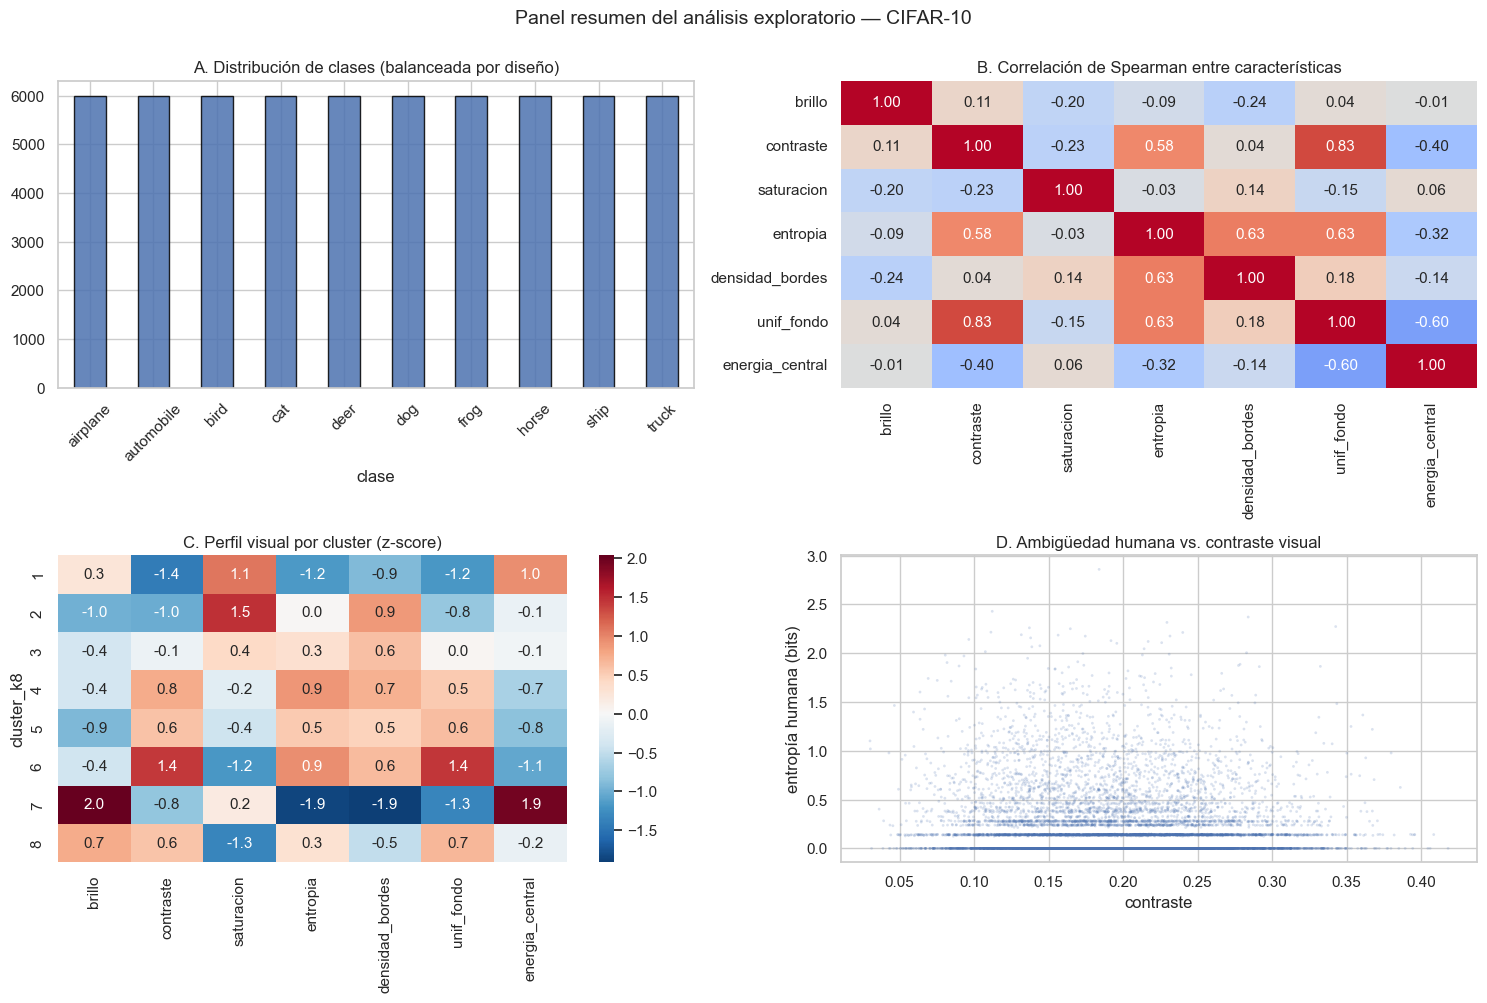

In [67]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

df["clase"].value_counts().sort_index().plot(kind="bar", ax=axes[0, 0],
                                             edgecolor="black", alpha=0.85)
axes[0, 0].set_title("A. Distribución de clases (balanceada por diseño)")
axes[0, 0].tick_params(axis="x", rotation=45)

sns.heatmap(corr_s, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            ax=axes[0, 1], cbar=False)
axes[0, 1].set_title("B. Correlación de Spearman entre características")

perfil = dsub.groupby("cluster_k8", observed=True)[VARS_NUM].mean()
perfil_z = (perfil - perfil.mean()) / perfil.std()
sns.heatmap(perfil_z, annot=True, fmt=".1f", cmap="RdBu_r", center=0, ax=axes[1, 0])
axes[1, 0].set_title("C. Perfil visual por cluster (z-score)")

if "entropia_humana" in df.columns:
    axes[1, 1].scatter(dtest["contraste"], dtest["entropia_humana"],
                       s=4, alpha=0.2, edgecolor="none")
    axes[1, 1].set_xlabel("contraste"); axes[1, 1].set_ylabel("entropía humana (bits)")
    axes[1, 1].set_title("D. Ambigüedad humana vs. contraste visual")
else:
    axes[1, 1].axis("off")

fig.suptitle("Panel resumen del análisis exploratorio — CIFAR-10", y=1.0, fontsize=14)
plt.tight_layout()
plt.savefig(DIR_FIG / "fig14_dashboard_resumen.png")
plt.show()

## 13. Exportación

Guardamos la tabla final, que es el insumo directo de la herramienta D3.js.

In [68]:
dsub.to_parquet(DIR_PROC / "tabla_final_clusters.parquet", index=False)
df.to_parquet(DIR_PROC / "tabla_final_completa.parquet", index=False)

# JSON compacto para la página web (submuestra con clusters)
cols_web = ["img_id", "clase", "cluster_k8", "cluster_k18"] + VARS_NUM
dsub[cols_web].to_json(DIR_PROC / "datos_web.json", orient="records")

print("figuras generadas:")
for p in sorted(DIR_FIG.glob("*.png")):
    print("  ", p.name)

figuras generadas:
   fig02_muestra_imagenes.png
   fig03_histogramas_caracteristicas.png
   fig04_boxplots_por_clase.png
   fig05_matriz_correlacion.png
   fig06_pairplot_caracteristicas.png
   fig07_calidad_datos.png
   fig08_h1_matriz_clase_cluster.png
   fig09_h1_perfil_clusters.png
   fig10_h2_fragmentacion_clases.png
   fig11_h2_subgrupos_clase.png
   fig12_h3_ambiguedad_distribucion.png
   fig13_h3_ambiguedad_vs_caracteristicas.png
   fig14_dashboard_resumen.png


## 14. Puente hacia el proyecto de Visual Analytics

Lo que este EDA deja fijado para la etapa siguiente:

| Hallazgo | Requisito de la herramienta |
|---|---|
| Clusters mixtos con perfil visual propio (H1) | Panel de características acoplado a la selección del treemap |
| Fragmentación intra-clase (H2) | Zoom semántico + comparación de subgrupos lado a lado |
| Ambigüedad humana concentrada (H3) | Resaltado de imágenes dudosas como apoyo al re-etiquetado |
| Escalas heterogéneas y atípicos | Sliders de filtrado por rango, con normalización explícita |
| Costo `O(n²)` del clustering | Precomputar el dendrograma en Python y exportarlo como JSON anidado |

La última fila es importante: DendroMap hace exactamente eso SciPy calcula el
dendrograma una sola vez y lo exporta como JSON, mientras D3.js solo se ocupa del
render y la interacción. Nuestra arquitectura sigue el mismo reparto.